In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
%matplotlib inline

In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure plots display inline (for Jupyter Notebooks)
%matplotlib inline

# Load the dataset
df = pd.read_csv("AEP_hourly.csv")

# Display separators for better readability
print("=" * 50)
print("First Five Rows\n")
print(df.head(2), "\n")

print("=" * 50)
print("Information About Dataset\n")
print(df.info(), "\n")

print("=" * 50)
print("Describe the Dataset\n")
print(df.describe(), "\n")

print("=" * 50)
print("Null Values in Dataset\n")
print(df.isnull().sum(), "\n")

First Five Rows

              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0 

Information About Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB
None 

Describe the Dataset

              AEP_MW
count  121273.000000
mean    15499.513717
std      2591.399065
min      9581.000000
25%     13630.000000
50%     15310.000000
75%     17200.000000
max     25695.000000 

Null Values in Dataset

Datetime    0
AEP_MW      0
dtype: int64 



In [ ]:
import pandas as pd

# Assuming df is your DataFrame and it has a 'Datetime' column
df['Datetime'] = pd.to_datetime(df['Datetime'])  # Convert to datetime

# Extracting Year, Month, Day, Time, and Week
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Time'] = df['Datetime'].dt.time
df['Week'] = df['Datetime'].dt.isocalendar().week

# Setting the Datetime column as the index
dataset = df.set_index('Datetime')

# Display the first row
print(dataset.head(1))

                      AEP_MW  Year  Month  Day      Time  Week
Datetime                                                      
2004-12-31 01:00:00  13478.0  2004     12   31  01:00:00    53


In [ ]:
print(df.Year.unique(),"\n")
print("Total Number of Unique Year",df.Year.nunique(),"\n")

[2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018] 

Total Number of Unique Year 15 



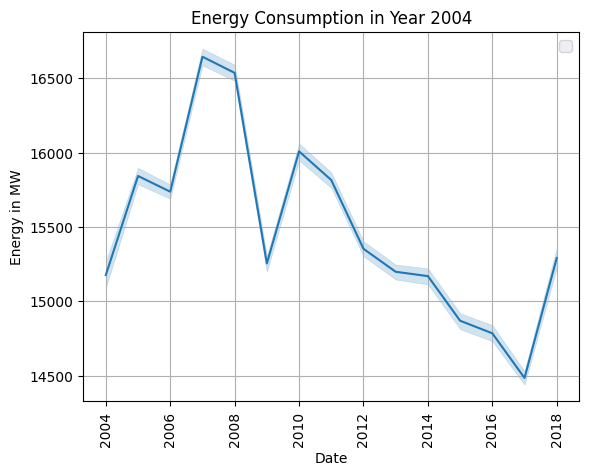

In [ ]:
from matplotlib import style
import matplotlib.pyplot as plt
import seaborn as sns

# Define the figure and axes
fig = plt.figure()
ax1 = plt.subplot2grid((1, 1), (0, 0))

# Use ggplot style
style.use('ggplot')

# Plot the data using seaborn
sns.lineplot(x="Year", y="AEP_MW", data=df)

# Set figure size
sns.set(rc={'figure.figsize': (15, 6)})

# Set title and axis labels
plt.title("Energy Consumption in Year 2004")
plt.xlabel("Date")
plt.ylabel("Energy in MW")

# Add grid and legend
plt.grid(True)
plt.legend()

# Rotate x-axis tick labels for better readability
for label in ax1.xaxis.get_ticklabels():
    label.set_rotation(90)

# Show the plot
plt.show()

Date range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Available years in the dataset: Index(['2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018'],
      dtype='object', name='Datetime')


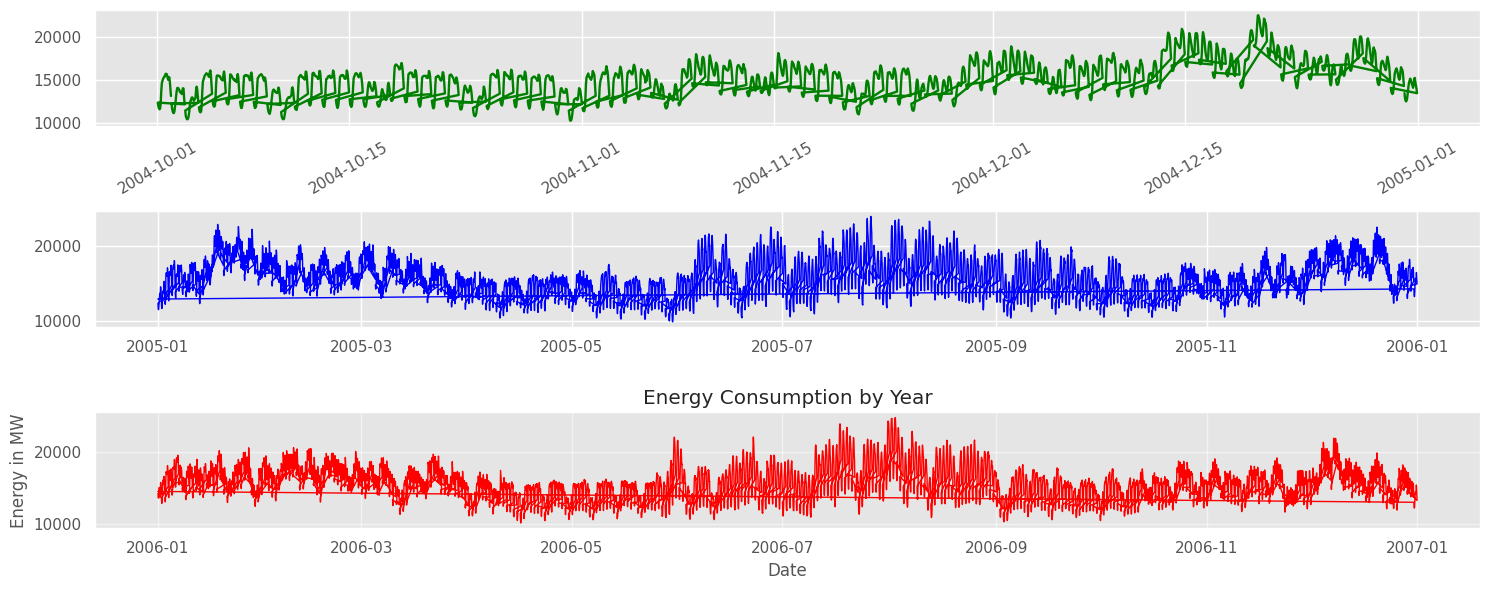

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style

# Assuming 'dataset' is your DataFrame
# Convert the 'Date' column to datetime if it's not already
# Check if 'Date' is a column, otherwise use the index
if 'Date' in dataset.columns:
    dataset['Date'] = pd.to_datetime(dataset['Date'])
    dataset.set_index('Date', inplace=True)
else:
    # Assuming 'Date' is already the index
    # Convert the index to datetime if it's not already
    if not isinstance(dataset.index, pd.DatetimeIndex):
        dataset.index = pd.to_datetime(dataset.index)


# Check the range of dates in the dataset
print("Date range:", dataset.index.min(), "to", dataset.index.max())

# Available years in the dataset
available_years = dataset.index.strftime('%Y').unique()
print("Available years in the dataset:", available_years)

# Plot data only for available years
fig = plt.figure()
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312)
ax3 = fig.add_subplot(313)

style.use('ggplot')

# Plot data for 2004 if available
if '2004' in available_years:
    y_2004 = dataset.loc['2004']['AEP_MW'].to_list()
    x_2004 = dataset.loc['2004'].index.to_list()
    ax1.plot(x_2004, y_2004, color="green", linewidth=1.7)
else:
    print("No data available for 2004")

# Plot data for 2005 if available
if '2005' in available_years:
    y_2005 = dataset.loc['2005']['AEP_MW'].to_list()
    x_2005 = dataset.loc['2005'].index.to_list()
    ax2.plot(x_2005, y_2005, color="blue", linewidth=1)
else:
    print("No data available for 2005")

# Plot data for 2006 if available
if '2006' in available_years:
    y_2006 = dataset.loc['2006']['AEP_MW'].to_list()
    x_2006 = dataset.loc['2006'].index.to_list()
    ax3.plot(x_2006, y_2006, color="red", linewidth=1)
else:
    print("No data available for 2006")

# Configure plot appearance
plt.rcParams['figure.figsize'] = (18, 8)
plt.title('Energy Consumption by Year')
plt.xlabel('Date')
plt.ylabel('Energy in MW')
plt.grid(True, alpha=0.5)

# Rotate x-axis labels for better readability
for label in ax1.xaxis.get_ticklabels():
    label.set_rotation(30)

plt.tight_layout()


<ipython-input-64-24cb102886dc>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['AEP_MW'])


Text(0.5, 1.0, 'Energy Distribution')

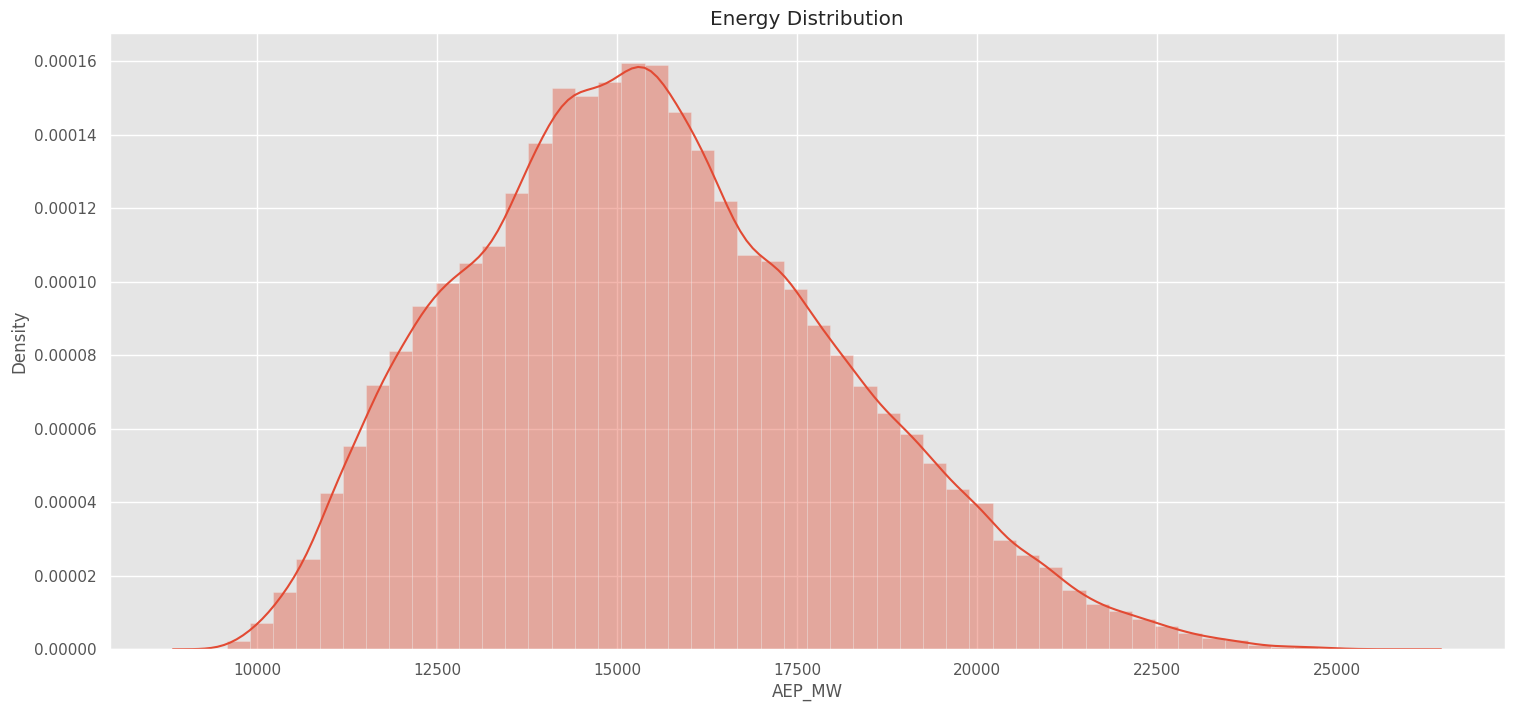

In [ ]:
sns.distplot(dataset['AEP_MW'])
plt.title("Energy Distribution")

In [ ]:
NewDataSet=dataset.resample('D').mean()

In [ ]:
print("Old Dataset",dataset.shape)
print("New Dataset",NewDataSet.shape)

Old Dataset (121273, 6)
New Dataset (5055, 6)


In [ ]:
TestData=NewDataSet.tail(100)
Training_Set=NewDataSet.iloc[:,0:1]
Training_Set=Training_Set[:-60]

In [ ]:
print("Training Set Shape",Training_Set.shape)
print("Test Set Shape",TestData.shape)

Training Set Shape (4995, 1)
Test Set Shape (100, 6)


In [ ]:
Training_Set=Training_Set.values
sc=MinMaxScaler(feature_range=(0,1))
Train=sc.fit_transform(Training_Set)

In [ ]:
X_Train = []
Y_Train = []

# Range should be from 60 values to END
for i in range(60, Train.shape[0]):
    # X_Train 0-59
    X_Train.append(Train[i-60:i])

    # Y would be 60th value based on past 60 values
    Y_Train.append(Train[i])

# Convert into Numpy Array
X_Train = np.array(X_Train)
Y_Train = np.array(Y_Train)

print(X_Train.shape)
print(Y_Train.shape)

(4935, 60, 1)
(4935, 1)


In [ ]:
Train=np.reshape(X_Train,newshape=(X_Train.shape[0],X_Train.shape[1],1))
X_Train.shape

(4935, 60, 1)

In [ ]:
# Initialize the RNN model
regressor = Sequential()

# Adding the first LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error')

# You can then train the model like this:
# regressor.fit(X_train, y_train, epochs=100, batch_size=32)

NameError: name 'Sequential' is not defined

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

# Initialize the RNN model
regressor = Sequential()

# Adding the first LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding a fourth LSTM layer and some Dropout regularization
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error')

# You can then train the model like this:
# regressor.fit(X_train, y_train, epochs=100, batch_size=32)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compiling the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error')

# Fitting the RNN to the Training set
regressor.fit(X_Train, Y_Train, epochs=50, batch_size=32)

Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 36s 128ms/step - loss: 0.0323
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - loss: 0.0185
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.0169
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.0162
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - loss: 0.0161
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.0153
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - loss: 0.0150
Epoch 8/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - loss: 0.0146
Epoch 9/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - loss: 0.0130
Epoch 10/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.0108
Epoch 11/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - loss: 0.0095
Epoch 12/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - loss: 0.0090
Epoch 13/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 40s 137ms/step - loss: 0.0087
Epoch 14/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - loss: 0.0079
Epoch 15/50
155

In [ ]:
TestData.head(2)

,AEP_MW,Year,Month,Day,Time,Week
Datetime,,,,,,
2018-04-26,13157.791667,2018.0,4.0,26.0,NaT,17.0
2018-04-27,12964.000000,2018.0,4.0,27.0,NaT,17.0


In [ ]:
TestData.shape

(100, 6)

In [ ]:
NewDataSet.shape

(5055, 6)

In [ ]:
Df_Total=pd.concat((NewDataSet[["AEP_MW"]],TestData[["AEP_MW"]]),axis=0)

In [ ]:
Df_Total.shape

(5155, 1)

In [ ]:
inputs=Df_Total[len(Df_Total)-len(TestData)-60:].values
inputs.shape

(160, 1)

In [ ]:
# Inputs for prediction from the last part of the dataset
inputs = Df_Total[len(Df_Total) - len(TestData) - 60:].values
inputs = inputs.reshape(-1, 1)

# Normalize the dataset
inputs = sc.transform(inputs)

# Prepare the test data for prediction
X_test = []
for i in range(60, 160):
    X_test.append(inputs[i-60:i])

# Convert list to numpy array
X_test = np.array(X_test)

# Reshape before passing to the network
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Pass the test data to the trained model
predicted_stock_price = regressor.predict(X_test)

# Inverse transform to get back the original scale
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step


In [ ]:
# Get the actual values for comparison
True_MegaWatt = TestData['AEP_MW'].to_list()  # Replace 'AEP_MW' with your actual column name
Predicted_MegaWatt = predicted_stock_price
dates = TestData.index.to_list()

# Create a DataFrame to compare predictions
Machine_Df = pd.DataFrame(data={
    "Date": dates,
    "TrueMegaWatt": True_MegaWatt,
    "PredictedMegaWatt": [x[0] for x in Predicted_MegaWatt]
})

# Display the DataFrame
print(Machine_Df)

         Date  TrueMegaWatt  PredictedMegaWatt
0  2018-04-26  13157.791667       13813.198242
1  2018-04-27  12964.000000       13088.002930
2  2018-04-28  12237.583333       14745.475586
3  2018-04-29  12156.791667       13574.484375
4  2018-04-30  13443.500000       13162.419922
5  2018-05-01  13251.875000       14246.019531
6  2018-05-02  13641.166667       13257.900391
7  2018-05-03  14217.250000       13202.319336
8  2018-05-04  13725.625000       14396.852539
9  2018-05-05  11902.166667       14744.955078
10 2018-05-06  11680.083333       13000.376953
11 2018-05-07  12972.500000       12701.108398
12 2018-05-08  13295.083333       13714.217773
13 2018-05-09  13688.750000       13356.170898
14 2018-05-10  13993.250000       13321.802734
15 2018-05-11  13525.166667       13987.220703
16 2018-05-12  12942.916667       14311.465820
17 2018-05-13  12832.541667       13559.872070
18 2018-05-14  15004.750000       13338.168945
19 2018-05-15  15171.791667       15583.829102
20 2018-05-16

In [ ]:
Machine_Df

,Date,TrueMegaWatt,PredictedMegaWatt
0,2018-04-26,13157.791667,13813.198242
1,2018-04-27,12964.000000,13088.002930
2,2018-04-28,12237.583333,14745.475586
3,2018-04-29,12156.791667,13574.484375
4,2018-04-30,13443.500000,13162.419922
5,2018-05-01,13251.875000,14246.019531
6,2018-05-02,13641.166667,13257.900391
7,2018-05-03,14217.250000,13202.319336
8,2018-05-04,13725.625000,14396.852539
9,2018-05-05,11902.166667,14744.955078


In [ ]:
True_MegaWatt=TestData["AEP_MW"].to_list()
Predicted_MegaWatt=[x[0] for x in Predicted_MegaWatt]
dates=TestData.index.to_list()

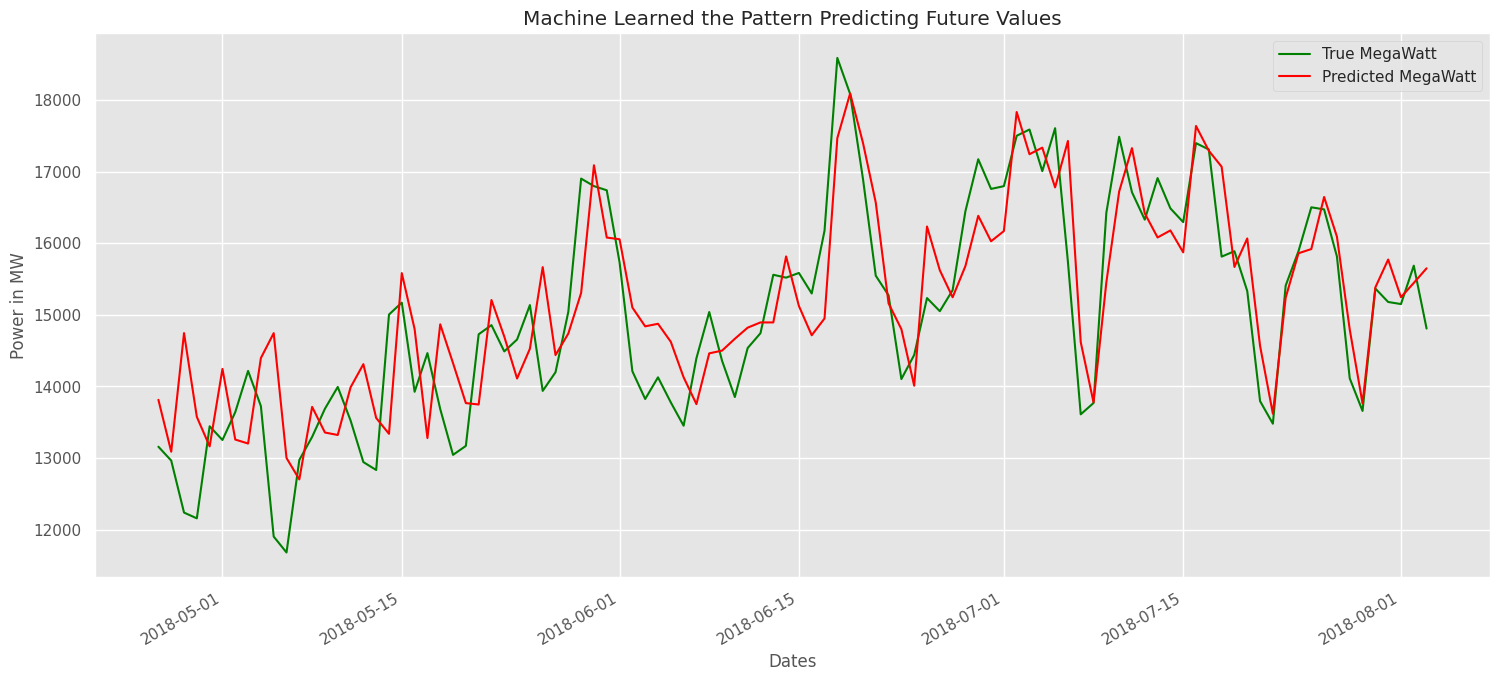

In [ ]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

x = dates
y = True_MegaWatt
y1 = Predicted_MegaWatt

# Plotting the true and predicted values with labels
plt.plot(x, y, color="green", label="True MegaWatt")
plt.plot(x, y1, color="red", label="Predicted MegaWatt")

# Beautify the x-labels
plt.gcf().autofmt_xdate()
plt.xlabel('Dates')
plt.ylabel('Power in MW')
plt.title('Machine Learned the Pattern Predicting Future Values')

# Adding the legend to the plot
plt.legend()